In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set style
sns.set_style("whitegrid")
np.random.seed(42)

# create a realistic student dataset
df = pd.DataFrame({
    "age"        : np.random.randint(18, 30, 200),
    "marks"      : np.concatenate([
                        np.random.normal(65, 10, 180),  # most students
                        np.random.normal(95, 2, 20)     # a few toppers
                   ]),
    "fees_paid"  : np.random.exponential(scale=50000, size=200),
    "gender"     : np.random.choice(["Male","Female"], 200, p=[0.55, 0.45]),
    "grade"      : np.random.choice(["A","B","C","D"], 200, p=[0.2,0.4,0.3,0.1]),
    "city"       : np.random.choice(["Mumbai","Delhi","Surat","Pune"], 200)
})

# add some missing values (realistic)
df.loc[np.random.choice(df.index, 10), "marks"] = np.nan
df.loc[np.random.choice(df.index, 5), "age"]   = np.nan

print(df.shape)    # (200, 6)
print(df.head())

(200, 6)
    age      marks      fees_paid  gender grade    city
0  24.0  69.529363    9766.664802    Male     B   Delhi
1  21.0  63.339391   69437.819800    Male     B  Mumbai
2  28.0  67.149388   82210.459162    Male     D   Surat
3  25.0        NaN  232850.244507    Male     A   Surat
4  22.0  55.569432   26603.967708  Female     B   Surat


### Step 1 : Look at the data

In [2]:
# basic info
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())

Shape: (200, 6)

Column types:
 age          float64
marks        float64
fees_paid    float64
gender           str
grade            str
city             str
dtype: object

Missing values:
 age           5
marks        10
fees_paid     0
gender        0
grade         0
city          0
dtype: int64

Basic stats:
               age       marks      fees_paid
count  195.000000  190.000000     200.000000
mean    24.030769   69.080959   60546.713718
std      3.514195   12.756657   61685.207263
min     18.000000   45.050384     544.840331
25%     21.000000   60.135094   19054.252521
50%     24.000000   66.699279   40444.031409
75%     27.000000   75.640048   83865.743565
max     29.000000   99.222635  408622.279891


### Step 2 : Numerical analysis - Marks Column

> Here the number of null values in columns is very less in compare to the entire dataset so we drop it

In [3]:
df.isnull().sum()
col = df["marks"].dropna()

In [4]:
# Central tendency count
print(f"Mean   : {col.mean():.2f}")
print(f"Median : {col.median():.2f}")
print(f"Mode   : {col.mode()[0]:.2f}")

Mean   : 69.08
Median : 66.70
Mode   : 45.05


In [5]:
# Measure of spread
print(f"Min    : {col.min():.2f}")
print(f"Max    : {col.max():.2f}")
print(f"Range  : {col.max() - col.min():.2f}")
print(f"Std    : {col.std():.2f}")
print(f"Var    : {col.var():.2f}")
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
print(f"Q1     : {Q1:.2f}")
print(f"Q3     : {Q3:.2f}")
print(f"IQR    : {IQR:.2f}")

Min    : 45.05
Max    : 99.22
Range  : 54.17
Std    : 12.76
Var    : 162.73
Q1     : 60.14
Q3     : 75.64
IQR    : 15.50


In [7]:
# Outlier detection using IQR
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = col[(col < lower) | (col > upper)]
print(f"Lower fence : {lower:.2f}")
print(f"Upper fence : {upper:.2f}")
print(f"Outliers    : {len(outliers)} found")
print(outliers.values)

Lower fence : 36.88
Upper fence : 98.90
Outliers    : 1 found
[99.22263528]


### Step 3 : visualization of numerical data (Makrs)

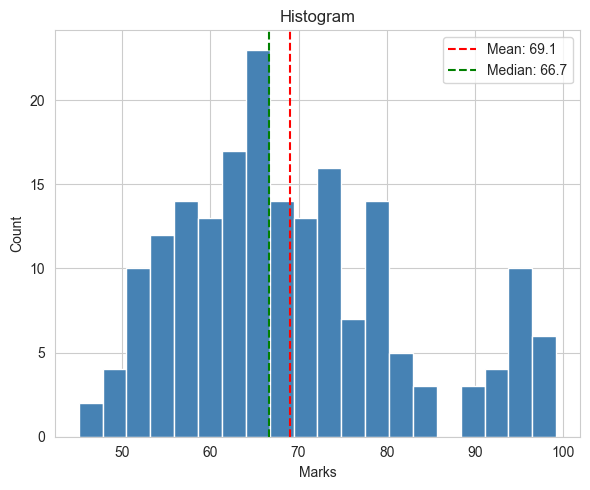

In [14]:
# histogram
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(col, bins=20, color='steelblue', edgecolor='white')
ax.axvline(col.mean(),   color='red',   linestyle='--', label=f'Mean: {col.mean():.1f}')
ax.axvline(col.median(), color='green', linestyle='--', label=f'Median: {col.median():.1f}')
ax.set_title("Histogram")
ax.set_xlabel("Marks")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

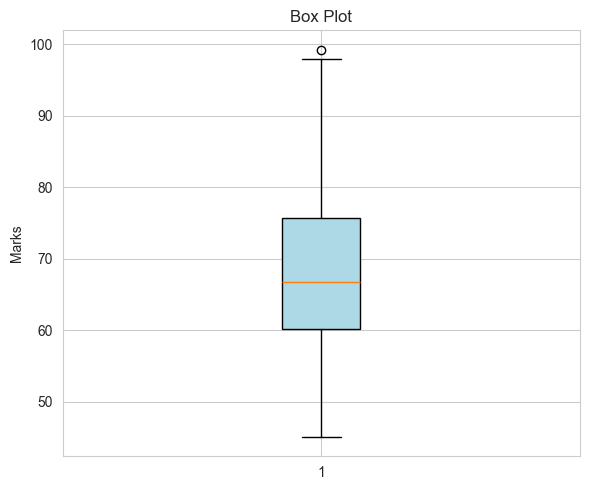

In [15]:
# Box plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(col, vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title("Box Plot")
ax.set_ylabel("Marks")
plt.tight_layout()
plt.show()

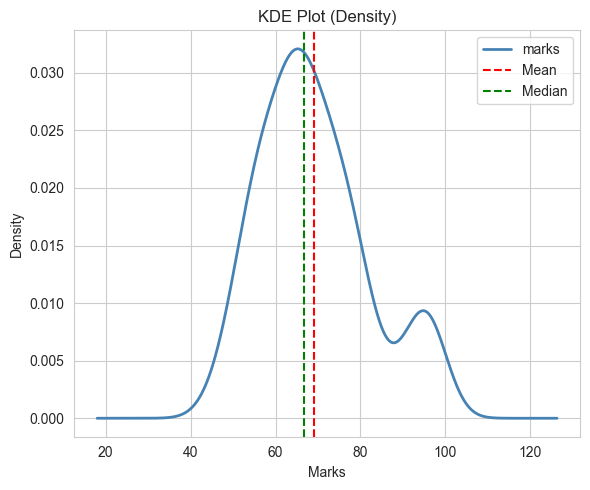

In [16]:
# KDE plot
fig, ax = plt.subplots(figsize=(6, 5))
col.plot.kde(ax=ax, color='steelblue', linewidth=2)
ax.axvline(col.mean(),   color='red',   linestyle='--', label='Mean')
ax.axvline(col.median(), color='green', linestyle='--', label='Median')
ax.set_title("KDE Plot (Density)")
ax.set_xlabel("Marks")
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 : Categorical analysis : Grade Column

In [12]:
col_cat = df["grade"]
print(col_cat.value_counts())
print(col_cat.value_counts(normalize=True).mul(100).round(2).astype(str) + "%")
print(f"\nMode (most common): {col_cat.mode()[0]}")
print(f"Unique categories : {col_cat.nunique()}")

grade
B    87
C    49
A    46
D    18
Name: count, dtype: int64
grade
B    43.5%
C    24.5%
A    23.0%
D     9.0%
Name: proportion, dtype: str

Mode (most common): B
Unique categories : 4


### Step 5 : Visualization of categorical column (Grade)

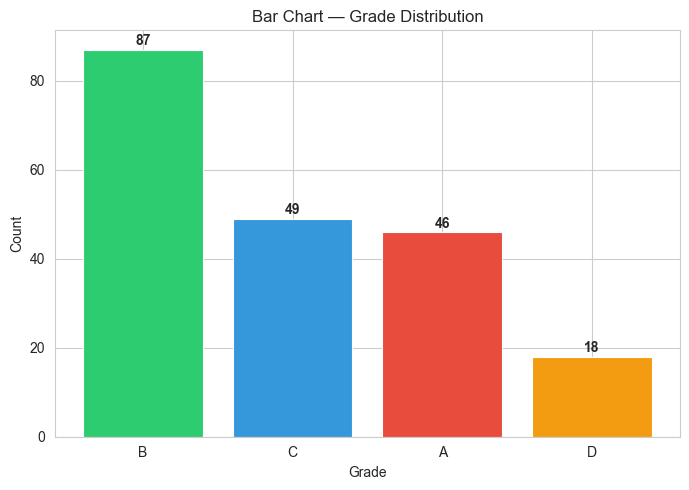

In [17]:
# Bar plot
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["grade"].value_counts()
ax.bar(counts.index, counts.values,
       color=['#2ecc71','#3498db','#e74c3c','#f39c12'],
       edgecolor='white', linewidth=0.8)
for i, (idx, val) in enumerate(counts.items()):
    ax.text(i, val + 1, str(val), ha='center', fontweight='bold')
ax.set_title("Bar Chart — Grade Distribution")
ax.set_xlabel("Grade")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

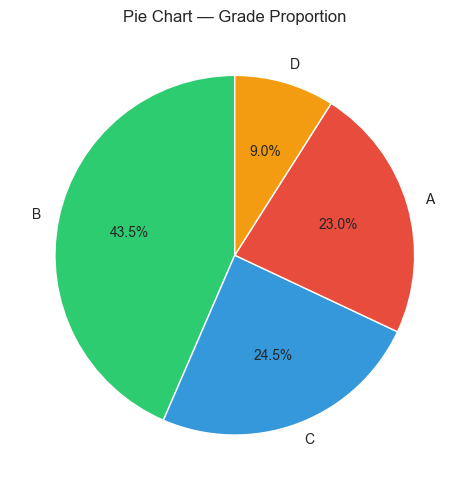

In [18]:
# Pie chart
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["grade"].value_counts()
ax.pie(counts.values,
       labels=counts.index,
       autopct='%1.1f%%',
       colors=['#2ecc71','#3498db','#e74c3c','#f39c12'],
       startangle=90)
ax.set_title("Pie Chart — Grade Proportion")
plt.tight_layout()
plt.show()